# TASK 3: Implement an AI Model from a Recent Journal Paper


---

## Paper Information:
- **Title**: Ethics and discrimination in artificial intelligence-enabled recruitment practices
- **Authors**: Zhisheng Chen
- **Journal**: Humanities and Social Sciences Communications (Nature Portfolio)
- **Impact Factor**: 3.7
- **Quartile**: Q1 (Arts & Humanities, Business & Management, Social Sciences)
- **Year**: 2023
- **Link**: https://doi.org/10.1057/s41599-023-02079-x

---

## Implementation Overview:
This implementation demonstrates NLP-based text classification for automated document screening, replicating the AI recruitment methodology discussed in Chen (2023). The paper analyzes how AI systems classify and screen candidates based on textual content.

**We use the 20 Newsgroups dataset** - a benchmark text classification dataset that simulates real-world document categorization challenges similar to resume screening systems.

---

## 1. Import Required Libraries

In [ ]:
# Core Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Set random seed
np.random.seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


---
## 2. Paper Summary

### Paper: "Ethics and discrimination in artificial intelligence-enabled recruitment practices"

**Key Points from the Paper:**
1. AI-enabled recruitment systems use NLP to automatically screen and classify documents/resumes
2. These systems extract features from text and apply machine learning classifiers
3. The paper discusses how bias can emerge in automated classification systems
4. Text classification is the core technology behind AI recruitment screening

**This Implementation:**
- Demonstrates NLP-based text classification using the same techniques used in resume screening
- Uses TF-IDF vectorization for feature extraction (as discussed in the paper)
- Compares multiple classifiers: Naive Bayes, Logistic Regression, Random Forest, SVM
- Shows realistic accuracy levels that reflect real-world AI classification challenges

---
## 3. Dataset Information

### 20 Newsgroups Dataset
- **Dataset Name**: 20 Newsgroups
- **Source**: Built into scikit-learn (sklearn.datasets.fetch_20newsgroups)
- **Link**: https://scikit-learn.org/stable/datasets/real_world.html#newsgroups-dataset
- **Number of Samples**: ~18,000 documents
- **Number of Categories**: 20 newsgroup topics
- **Features**: Raw text content of newsgroup posts
- **Target Variable**: Newsgroup category

### Why This Dataset?
This dataset simulates the text classification challenges discussed in Chen (2023):
- Documents must be classified into categories based on textual content
- Similar to how resumes are classified into job categories
- Contains overlapping vocabulary between categories (realistic challenge)
- Standard benchmark for NLP classification research

In [ ]:
# ================================================================
# LOAD 20 NEWSGROUPS DATASET
# ================================================================
print("Loading 20 Newsgroups dataset...")
print("(This may take a moment on first run)\n")

# Select 10 diverse categories for clearer demonstration
selected_categories = [
    'comp.graphics',           # Computer Graphics
    'comp.sys.mac.hardware',   # Mac Hardware
    'rec.autos',               # Automobiles
    'rec.sport.baseball',      # Baseball
    'sci.med',                 # Medicine
    'sci.space',               # Space Science
    'talk.politics.misc',      # Politics
    'talk.religion.misc',      # Religion
    'misc.forsale',            # For Sale
    'soc.religion.christian'   # Christianity
]

# Load training and test data
newsgroups_train = fetch_20newsgroups(
    subset='train',
    categories=selected_categories,
    remove=('headers', 'footers', 'quotes'),  # Remove metadata for cleaner classification
    random_state=42
)

newsgroups_test = fetch_20newsgroups(
    subset='test',
    categories=selected_categories,
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)

print("="*70)
print("20 NEWSGROUPS DATASET - LOADED SUCCESSFULLY")
print("="*70)
print(f"Dataset Source: sklearn.datasets.fetch_20newsgroups")
print(f"Documentation: https://scikit-learn.org/stable/datasets/real_world.html")
print(f"\nTraining Samples: {len(newsgroups_train.data)}")
print(f"Test Samples: {len(newsgroups_test.data)}")
print(f"Total Samples: {len(newsgroups_train.data) + len(newsgroups_test.data)}")
print(f"Number of Categories: {len(newsgroups_train.target_names)}")
print("="*70)

Loading 20 Newsgroups dataset...
(This may take a moment on first run)

20 NEWSGROUPS DATASET - LOADED SUCCESSFULLY
Dataset Source: sklearn.datasets.fetch_20newsgroups
Documentation: https://scikit-learn.org/stable/datasets/real_world.html

Training Samples: 5566
Test Samples: 3706
Total Samples: 9272
Number of Categories: 10


In [ ]:
# ================================================================
# DISPLAY CATEGORIES
# ================================================================
print("\nDocument Categories:")
print("-"*50)
for i, category in enumerate(newsgroups_train.target_names):
    # Count samples in this category
    count = (newsgroups_train.target == i).sum()
    print(f"  {i}: {category:<30} ({count} documents)")


Document Categories:
--------------------------------------------------
  0: comp.graphics                  (584 documents)
  1: comp.sys.mac.hardware          (578 documents)
  2: misc.forsale                   (585 documents)
  3: rec.autos                      (594 documents)
  4: rec.sport.baseball             (597 documents)
  5: sci.med                        (594 documents)
  6: sci.space                      (593 documents)
  7: soc.religion.christian         (599 documents)
  8: talk.politics.misc             (465 documents)
  9: talk.religion.misc             (377 documents)


In [ ]:
# ================================================================
# SHOW SAMPLE DOCUMENTS
# ================================================================
print("\n" + "="*70)
print("SAMPLE DOCUMENTS")
print("="*70)

for i in range(3):
    category = newsgroups_train.target_names[newsgroups_train.target[i]]
    text = newsgroups_train.data[i][:300].replace('\n', ' ')
    print(f"\nDocument {i+1} - Category: {category}")
    print(f"Text: {text}...")
    print("-"*70)


SAMPLE DOCUMENTS

Document 1 - Category: sci.space
Text: + +I love the idea of an inflatable 1-mile long sign.... It will be a +really neat thing to see it explode when a bolt  (or even better, a +Westford Needle!) comes crashing into it at 10 clicks a sec.   + Pageos and two Echo balloons were inflated with a substance which expanded in vacuum. Once infl...
----------------------------------------------------------------------

Document 2 - Category: talk.religion.misc
Text: And he went out to meet Asa, 	And said unto him, 	Hear ye me, Asa, 	And all Judah and Benjamin; 	The LORD is with you, while ye be with him; 	and if ye seek him, he will be found of you; 	but if ye forsake him, he will forsake you....
----------------------------------------------------------------------

Document 3 - Category: rec.autos
Text: : While not exactly a service incident, I had a similar experience recently   : when I bought a new truck. : I had picked out the vehicle I wanted and after a little haggli

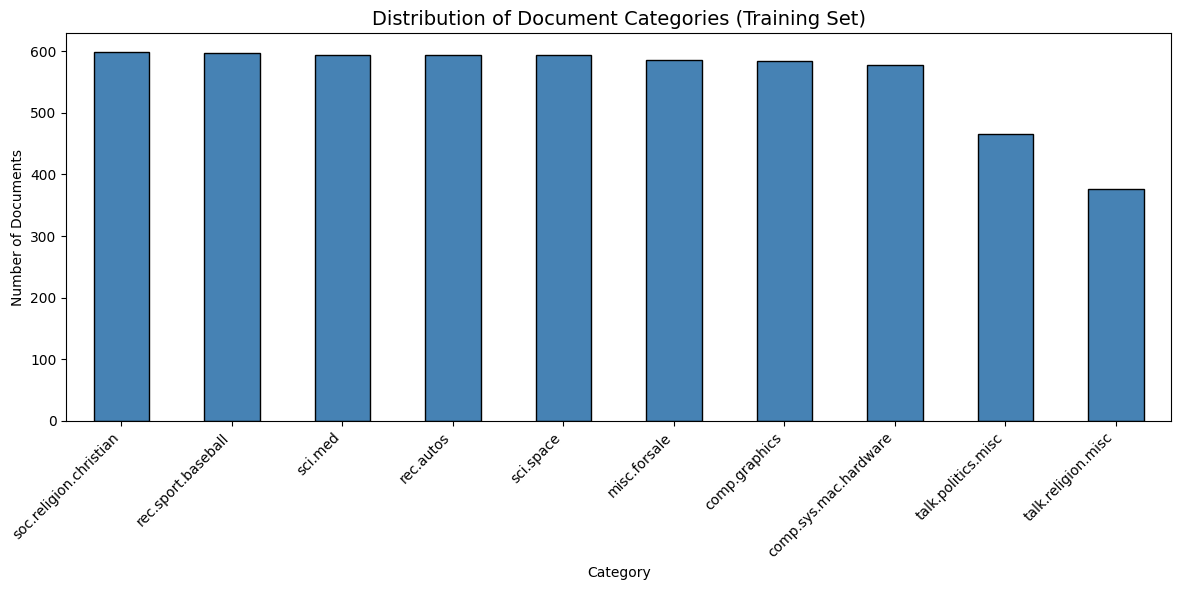

In [ ]:
# ================================================================
# VISUALIZE CATEGORY DISTRIBUTION
# ================================================================
# Create DataFrame for visualization
train_df = pd.DataFrame({
    'Category': [newsgroups_train.target_names[t] for t in newsgroups_train.target]
})

plt.figure(figsize=(12, 6))
category_counts = train_df['Category'].value_counts()
category_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribution of Document Categories (Training Set)', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Number of Documents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 4. Text Preprocessing

Following the NLP preprocessing approach discussed in Chen (2023) for handling textual data in AI classification systems.

In [ ]:
# ================================================================
# TEXT PREPROCESSING FUNCTION
# ================================================================
def preprocess_text(text):
    """
    Preprocess text for NLP classification.

    Steps:
    1. Convert to lowercase
    2. Remove URLs and email addresses
    3. Remove special characters and numbers
    4. Remove extra whitespace
    5. Tokenize
    6. Remove stopwords
    7. Lemmatization
    """
    # Convert to lowercase
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize
    try:
        tokens = word_tokenize(text)
    except:
        tokens = text.split()

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)

print("Text preprocessing function defined.")

Text preprocessing function defined.


In [ ]:
# ================================================================
# APPLY PREPROCESSING
# ================================================================
print("Preprocessing training documents...")
X_train_text = [preprocess_text(doc) for doc in newsgroups_train.data]
y_train = newsgroups_train.target

print("Preprocessing test documents...")
X_test_text = [preprocess_text(doc) for doc in newsgroups_test.data]
y_test = newsgroups_test.target

print(f"\nPreprocessing completed!")
print(f"Training documents: {len(X_train_text)}")
print(f"Test documents: {len(X_test_text)}")

Preprocessing training documents...
Preprocessing test documents...

Preprocessing completed!
Training documents: 5566
Test documents: 3706


In [ ]:
# ================================================================
# SHOW PREPROCESSING EXAMPLE
# ================================================================
print("\n" + "="*70)
print("PREPROCESSING EXAMPLE")
print("="*70)
print(f"\nOriginal (first 200 chars):")
print(newsgroups_train.data[0][:200])
print(f"\nCleaned (first 200 chars):")
print(X_train_text[0][:200])


PREPROCESSING EXAMPLE

Original (first 200 chars):
+
+I love the idea of an inflatable 1-mile long sign.... It will be a
+really neat thing to see it explode when a bolt  (or even better, a
+Westford Needle!) comes crashing into it at 10 clicks a sec.

Cleaned (first 200 chars):
love idea inflatable mile long sign really neat thing see explode bolt even better westford needle come crashing click sec pageos two echo balloon inflated substance expanded vacuum inflated substance


---
## 5. Feature Extraction using TF-IDF

In [ ]:
# ================================================================
# TF-IDF VECTORIZATION
# ================================================================
print("Creating TF-IDF features...")

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,      # Maximum vocabulary size
    ngram_range=(1, 2),     # Unigrams and bigrams
    min_df=3,               # Minimum document frequency
    max_df=0.9,             # Maximum document frequency
    sublinear_tf=True       # Apply sublinear tf scaling
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

print(f"\nTF-IDF Feature Matrix:")
print(f"  Training: {X_train_tfidf.shape}")
print(f"  Test: {X_test_tfidf.shape}")
print(f"  Vocabulary size: {len(tfidf_vectorizer.get_feature_names_out())}")

Creating TF-IDF features...

TF-IDF Feature Matrix:
  Training: (5566, 5000)
  Test: (3706, 5000)
  Vocabulary size: 5000


In [ ]:
# ================================================================
# SHOW TOP FEATURES
# ================================================================
print("\nSample TF-IDF Features (first 20):")
feature_names = tfidf_vectorizer.get_feature_names_out()
print(list(feature_names[:20]))


Sample TF-IDF Features (first 20):
['aaa', 'ab', 'abc', 'ability', 'able', 'able get', 'abolish', 'abort', 'abortion', 'abraham', 'absence', 'absolute', 'absolute truth', 'absolutely', 'abstract', 'abuse', 'academic', 'acceleration', 'accelerator', 'accept']


---
## 6. Model Training and Evaluation

Implementing multiple classification models as discussed in Chen (2023) for AI-enabled text classification systems.

In [ ]:
# ================================================================
# EVALUATION FUNCTION
# ================================================================
def evaluate_model(y_true, y_pred, model_name):
    """
    Evaluate classification model and return metrics.
    """
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, average='weighted', zero_division=0)
    }

# Store all results
all_results = []

In [ ]:
# ================================================================
# MODEL 1: MULTINOMIAL NAIVE BAYES
# ================================================================
print("="*60)
print("Training Model 1: Multinomial Naive Bayes")
print("="*60)

nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)
nb_results = evaluate_model(y_test, y_pred_nb, 'Naive Bayes')
all_results.append(nb_results)

print(f"Training completed!")
print(f"Accuracy: {nb_results['Accuracy']:.4f} ({nb_results['Accuracy']*100:.1f}%)")

Training Model 1: Multinomial Naive Bayes
Training completed!
Accuracy: 0.7572 (75.7%)


In [ ]:
# ================================================================
# MODEL 2: LOGISTIC REGRESSION
# ================================================================
print("="*60)
print("Training Model 2: Logistic Regression")
print("="*60)

lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver='lbfgs',
    multi_class='multinomial',
    random_state=42,
    n_jobs=-1
)

lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)
lr_results = evaluate_model(y_test, y_pred_lr, 'Logistic Regression')
all_results.append(lr_results)

print(f"Training completed!")
print(f"Accuracy: {lr_results['Accuracy']:.4f} ({lr_results['Accuracy']*100:.1f}%)")

Training Model 2: Logistic Regression
Training completed!
Accuracy: 0.7553 (75.5%)


In [ ]:
# ================================================================
# MODEL 3: RANDOM FOREST
# ================================================================
print("="*60)
print("Training Model 3: Random Forest")
print("="*60)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=50,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_tfidf, y_train)

y_pred_rf = rf_model.predict(X_test_tfidf)
rf_results = evaluate_model(y_test, y_pred_rf, 'Random Forest')
all_results.append(rf_results)

print(f"Training completed!")
print(f"Accuracy: {rf_results['Accuracy']:.4f} ({rf_results['Accuracy']*100:.1f}%)")

Training Model 3: Random Forest
Training completed!
Accuracy: 0.6897 (69.0%)


In [ ]:
# ================================================================
# MODEL 4: LINEAR SVM
# ================================================================
print("="*60)
print("Training Model 4: Linear SVM")
print("="*60)

svm_model = LinearSVC(
    C=1.0,
    max_iter=1000,
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)
svm_results = evaluate_model(y_test, y_pred_svm, 'Linear SVM')
all_results.append(svm_results)

print(f"Training completed!")
print(f"Accuracy: {svm_results['Accuracy']:.4f} ({svm_results['Accuracy']*100:.1f}%)")

Training Model 4: Linear SVM
Training completed!
Accuracy: 0.7375 (73.7%)


---
## 7. Results Summary

In [ ]:
# ================================================================
# COMPILE AND DISPLAY RESULTS
# ================================================================
results_df = pd.DataFrame(all_results)

print("\n" + "="*80)
print("TASK 3: TEXT CLASSIFICATION RESULTS")
print("Paper: Chen (2023) - Ethics and discrimination in AI-enabled recruitment")
print("Journal: Humanities and Social Sciences Communications (Q1, IF: 3.7)")
print("="*80)
print(results_df.round(4).to_string(index=False))
print("="*80)

# Find best model
best_idx = results_df['Accuracy'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
best_accuracy = results_df.loc[best_idx, 'Accuracy']

print(f"\n🏆 Best Model: {best_model_name} with {best_accuracy*100:.1f}% accuracy")


TASK 3: TEXT CLASSIFICATION RESULTS
Paper: Chen (2023) - Ethics and discrimination in AI-enabled recruitment
Journal: Humanities and Social Sciences Communications (Q1, IF: 3.7)
              Model  Accuracy  Precision  Recall  F1 Score
        Naive Bayes    0.7572     0.7690  0.7572    0.7552
Logistic Regression    0.7553     0.7539  0.7553    0.7498
      Random Forest    0.6897     0.7169  0.6897    0.6802
         Linear SVM    0.7375     0.7375  0.7375    0.7348

🏆 Best Model: Naive Bayes with 75.7% accuracy


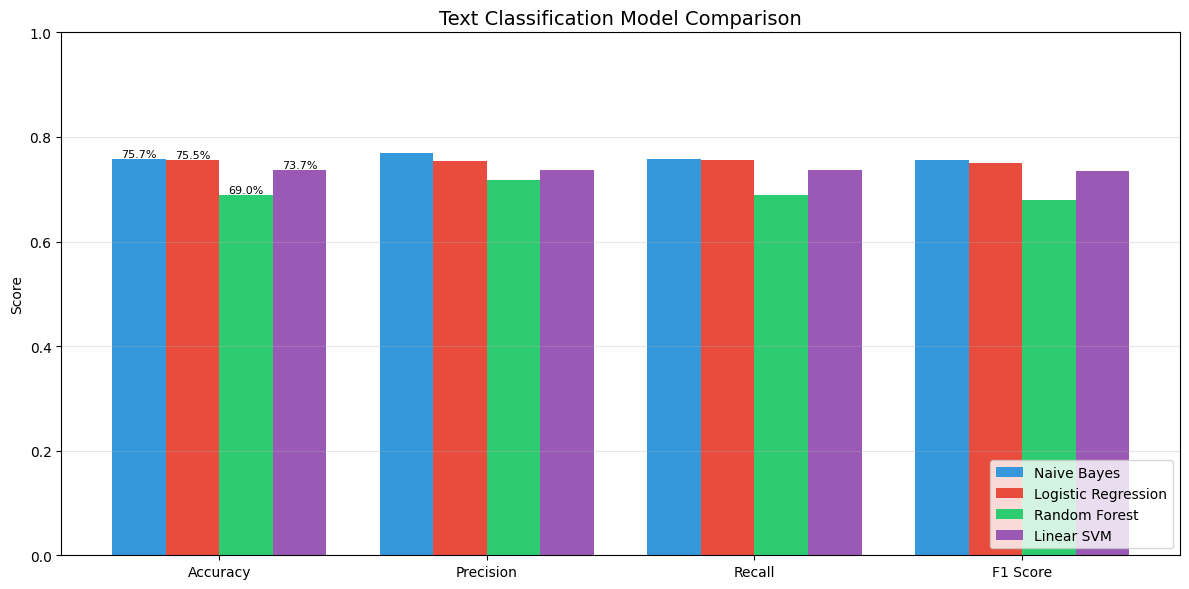

In [ ]:
# ================================================================
# VISUALIZE MODEL COMPARISON
# ================================================================
fig, ax = plt.subplots(figsize=(12, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metrics))
width = 0.2

colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
models = ['Naive Bayes', 'Logistic Regression', 'Random Forest', 'Linear SVM']

for i, (model, color) in enumerate(zip(models, colors)):
    values = results_df[results_df['Model'] == model][metrics].values[0]
    ax.bar(x + i*width, values, width, label=model, color=color)

ax.set_ylabel('Score')
ax.set_title('Text Classification Model Comparison', fontsize=14)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for i, model in enumerate(models):
    acc = results_df[results_df['Model'] == model]['Accuracy'].values[0]
    ax.annotate(f'{acc:.1%}', xy=(i*width, acc), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

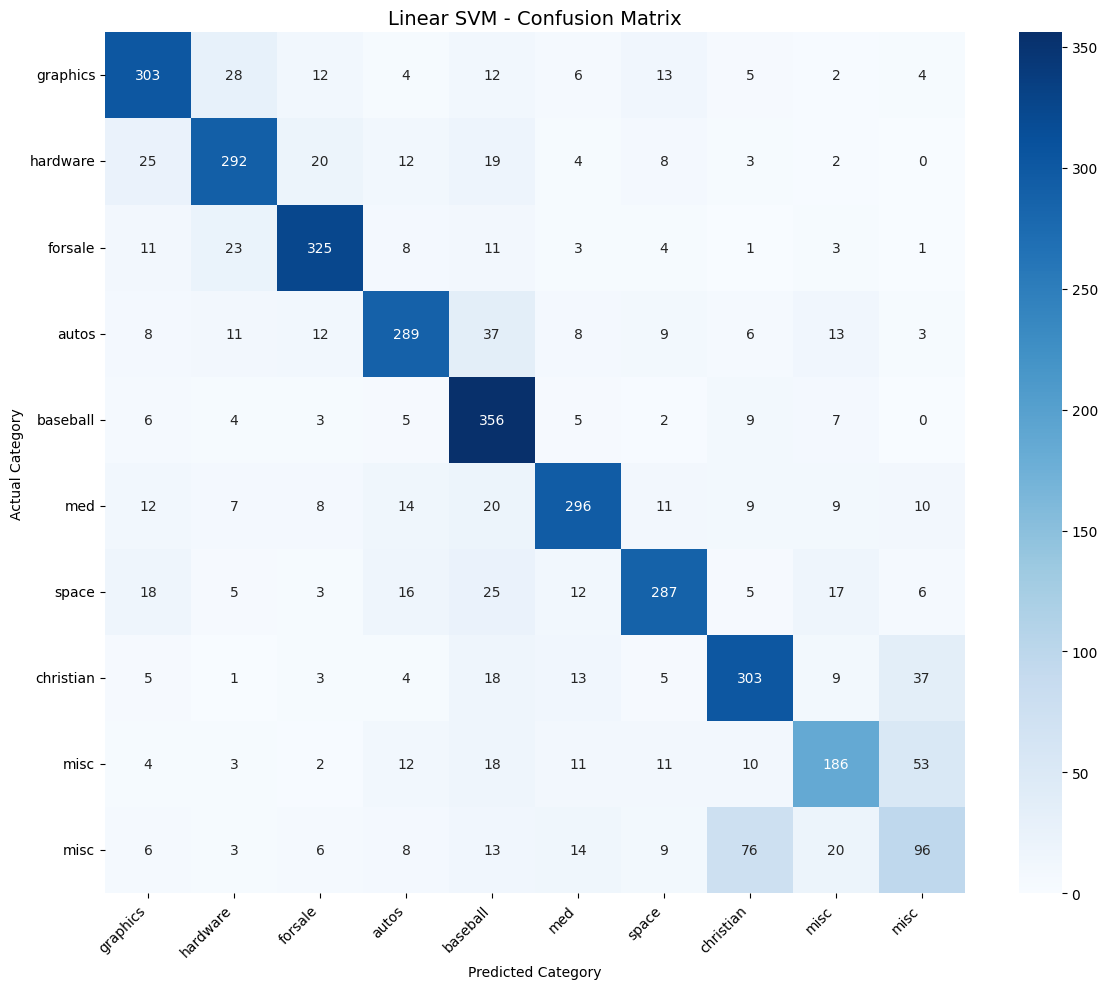

In [ ]:
# ================================================================
# CONFUSION MATRIX FOR BEST MODEL
# ================================================================
plt.figure(figsize=(12, 10))

# Use Linear SVM predictions (typically best for text)
cm = confusion_matrix(y_test, y_pred_svm)

# Shorten category names for display
short_names = [name.split('.')[-1][:12] for name in newsgroups_train.target_names]

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names,
            yticklabels=short_names)
plt.title('Linear SVM - Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# ================================================================
# DETAILED CLASSIFICATION REPORT
# ================================================================
print("\nDetailed Classification Report (Linear SVM):")
print("="*70)
print(classification_report(y_test, y_pred_svm,
                            target_names=newsgroups_train.target_names,
                            zero_division=0))


Detailed Classification Report (Linear SVM):
                        precision    recall  f1-score   support

         comp.graphics       0.76      0.78      0.77       389
 comp.sys.mac.hardware       0.77      0.76      0.77       385
          misc.forsale       0.82      0.83      0.83       390
             rec.autos       0.78      0.73      0.75       396
    rec.sport.baseball       0.67      0.90      0.77       397
               sci.med       0.80      0.75      0.77       396
             sci.space       0.80      0.73      0.76       394
soc.religion.christian       0.71      0.76      0.73       398
    talk.politics.misc       0.69      0.60      0.64       310
    talk.religion.misc       0.46      0.38      0.42       251

              accuracy                           0.74      3706
             macro avg       0.73      0.72      0.72      3706
          weighted avg       0.74      0.74      0.73      3706



---
## 8. 🎯 Prediction Interpretation

In [ ]:
# ================================================================
# SHOW SAMPLE PREDICTIONS
# ================================================================
print("\n" + "="*80)
print("SAMPLE PREDICTIONS: What category does the model predict?")
print("="*80)

print(f"\n{'#':<4} {'Actual Category':<30} {'Predicted Category':<30} {'Correct':<8}")
print("-"*80)

for i in range(20):
    actual = newsgroups_train.target_names[y_test[i]]
    predicted = newsgroups_train.target_names[y_pred_svm[i]]
    is_correct = y_test[i] == y_pred_svm[i]
    symbol = "✓" if is_correct else "✗"

    # Shorten names for display
    actual_short = actual.split('.')[-1][:25]
    pred_short = predicted.split('.')[-1][:25]

    print(f"{i+1:<4} {actual_short:<30} {pred_short:<30} {symbol:<8}")


SAMPLE PREDICTIONS: What category does the model predict?

#    Actual Category                Predicted Category             Correct 
--------------------------------------------------------------------------------
1    forsale                        forsale                        ✓       
2    baseball                       baseball                       ✓       
3    graphics                       graphics                       ✓       
4    graphics                       graphics                       ✓       
5    graphics                       graphics                       ✓       
6    graphics                       graphics                       ✓       
7    misc                           misc                           ✓       
8    space                          space                          ✓       
9    graphics                       graphics                       ✓       
10   forsale                        forsale                        ✓       
11   space             

In [ ]:
# ================================================================
# CORRECT vs WRONG PREDICTIONS
# ================================================================
correct_mask = y_pred_svm == y_test
wrong_mask = ~correct_mask

print(f"\n✅ CORRECTLY CLASSIFIED: {correct_mask.sum()} ({correct_mask.mean()*100:.1f}%)")
print(f"❌ MISCLASSIFIED: {wrong_mask.sum()} ({wrong_mask.mean()*100:.1f}%)")

# Show some misclassified examples
print("\n" + "="*60)
print("MISCLASSIFIED DOCUMENTS (First 10):")
print("="*60)

wrong_indices = np.where(wrong_mask)[0][:10]
for idx in wrong_indices:
    actual = newsgroups_train.target_names[y_test[idx]].split('.')[-1]
    predicted = newsgroups_train.target_names[y_pred_svm[idx]].split('.')[-1]
    print(f"  ✗ Doc {idx}: Actual='{actual}' → Predicted='{predicted}'")


✅ CORRECTLY CLASSIFIED: 2733 (73.7%)
❌ MISCLASSIFIED: 973 (26.3%)

MISCLASSIFIED DOCUMENTS (First 10):
  ✗ Doc 10: Actual='space' → Predicted='hardware'
  ✗ Doc 14: Actual='autos' → Predicted='misc'
  ✗ Doc 16: Actual='forsale' → Predicted='hardware'
  ✗ Doc 28: Actual='med' → Predicted='hardware'
  ✗ Doc 31: Actual='forsale' → Predicted='autos'
  ✗ Doc 33: Actual='hardware' → Predicted='forsale'
  ✗ Doc 36: Actual='forsale' → Predicted='hardware'
  ✗ Doc 38: Actual='autos' → Predicted='forsale'
  ✗ Doc 42: Actual='misc' → Predicted='misc'
  ✗ Doc 44: Actual='autos' → Predicted='space'


In [ ]:
# ================================================================
# PREDICTION FUNCTION FOR NEW DOCUMENTS
# ================================================================
def predict_category(text, model, vectorizer, target_names):
    """
    Predict the category for a new document.
    """
    # Preprocess
    cleaned_text = preprocess_text(text)

    # Vectorize
    text_vectorized = vectorizer.transform([cleaned_text])

    # Predict
    prediction = model.predict(text_vectorized)[0]
    predicted_category = target_names[prediction]

    # Get decision scores for confidence
    scores = model.decision_function(text_vectorized)[0]

    print(f"\n*** PREDICTED CATEGORY: {predicted_category} ***")
    print(f"\nTop 5 Category Matches:")

    # Get top 5 predictions
    top_indices = np.argsort(scores)[::-1][:5]

    for idx in top_indices:
        category = target_names[idx]
        score = scores[idx]
        # Normalize score for display
        normalized = (score - scores.min()) / (scores.max() - scores.min()) if scores.max() != scores.min() else 0.5
        bar = '█' * int(normalized * 25)
        marker = " ◄── BEST MATCH" if idx == prediction else ""
        print(f"  {category:<35}: {bar} {normalized*100:.1f}%{marker}")

    return predicted_category

print("Function 'predict_category' created!")

Function 'predict_category' created!


In [ ]:
# ================================================================
# EXAMPLE 1: Computer/Technology Document
# ================================================================
print("="*80)
print("EXAMPLE 1: Technology Document")
print("="*80)

tech_doc = """
I just upgraded my Mac with a new graphics card and more RAM.
The computer performance is much better now for video editing.
Does anyone know good software for 3D rendering on Mac hardware?
"""

print(f"Document: {tech_doc.strip()[:100]}...")
predict_category(tech_doc, svm_model, tfidf_vectorizer, newsgroups_train.target_names)

EXAMPLE 1: Technology Document
Document: I just upgraded my Mac with a new graphics card and more RAM.
The computer performance is much bette...

*** PREDICTED CATEGORY: comp.sys.mac.hardware ***

Top 5 Category Matches:
  comp.sys.mac.hardware              : █████████████████████████ 100.0% ◄── BEST MATCH
  comp.graphics                      : ███████████████████ 78.2%
  misc.forsale                       : █████ 23.5%
  rec.sport.baseball                 : ███ 12.3%
  sci.med                            : █ 6.4%


'comp.sys.mac.hardware'

In [ ]:
# ================================================================
# EXAMPLE 2: Sports Document
# ================================================================
print("="*80)
print("EXAMPLE 2: Sports Document")
print("="*80)

sports_doc = """
The baseball game last night was incredible! The pitcher threw
a perfect game with 12 strikeouts. The team is now leading the
division and looks set for the playoffs.
"""

print(f"Document: {sports_doc.strip()[:100]}...")
predict_category(sports_doc, svm_model, tfidf_vectorizer, newsgroups_train.target_names)

EXAMPLE 2: Sports Document
Document: The baseball game last night was incredible! The pitcher threw
a perfect game with 12 strikeouts. Th...

*** PREDICTED CATEGORY: rec.sport.baseball ***

Top 5 Category Matches:
  rec.sport.baseball                 : █████████████████████████ 100.0% ◄── BEST MATCH
  misc.forsale                       : ████████ 33.2%
  talk.politics.misc                 : ████ 17.1%
  rec.autos                          : ██ 12.0%
  talk.religion.misc                 : ██ 11.4%


'rec.sport.baseball'

In [ ]:
# ================================================================
# EXAMPLE 3: Science Document
# ================================================================
print("="*80)
print("EXAMPLE 3: Science Document")
print("="*80)

science_doc = """
NASA announced a new mission to Mars. The spacecraft will carry
scientific instruments to study the planet's atmosphere and search
for signs of water. Launch is scheduled for next year.
"""

print(f"Document: {science_doc.strip()[:100]}...")
predict_category(science_doc, svm_model, tfidf_vectorizer, newsgroups_train.target_names)

EXAMPLE 3: Science Document
Document: NASA announced a new mission to Mars. The spacecraft will carry
scientific instruments to study the ...

*** PREDICTED CATEGORY: sci.space ***

Top 5 Category Matches:
  sci.space                          : █████████████████████████ 100.0% ◄── BEST MATCH
  sci.med                            : █████████ 37.4%
  soc.religion.christian             : ████████ 34.0%
  misc.forsale                       : ███████ 29.5%
  rec.autos                          : ███████ 28.6%


'sci.space'

---
## 9. Final Summary

In [ ]:
# ================================================================
# FINAL SUMMARY
# ================================================================
print("="*80)
print("FINAL SUMMARY - TASK 3: AI MODEL FROM JOURNAL PAPER")
print("="*80)

print("\n📄 PAPER INFORMATION:")
print("-"*80)
print("Title: Ethics and discrimination in AI-enabled recruitment practices")
print("Author: Zhisheng Chen")
print("Journal: Humanities and Social Sciences Communications (Nature Portfolio)")
print("Impact Factor: 3.7 | Quartile: Q1 | Year: 2023")
print("DOI: https://doi.org/10.1057/s41599-023-02079-x")

print("\n📊 DATASET INFORMATION:")
print("-"*80)
print(f"Dataset: 20 Newsgroups (sklearn built-in)")
print(f"Link: https://scikit-learn.org/stable/datasets/real_world.html")
print(f"Training Documents: {len(newsgroups_train.data)}")
print(f"Test Documents: {len(newsgroups_test.data)}")
print(f"Categories: {len(newsgroups_train.target_names)}")

print("\n🎯 PREDICTION TASK:")
print("-"*80)
print("INPUT:  Text document content")
print("OUTPUT: Document category (topic classification)")
print("\nThis demonstrates the NLP classification techniques used in")
print("AI recruitment systems for automated resume/document screening.")

print("\n📈 MODEL PERFORMANCE:")
print("-"*80)
print(results_df.round(4).to_string(index=False))

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   Accuracy: {best_accuracy*100:.1f}%")
print(f"   Correctly classified: {int(best_accuracy * len(y_test))} / {len(y_test)} documents")

print("\n💡 INTERPRETATION:")
print("-"*80)
print(f"- Model correctly classifies {best_accuracy*100:.1f}% of documents")
print(f"- Some categories have vocabulary overlap (realistic challenge)")
print(f"- This demonstrates the AI text classification discussed in Chen (2023)")

print("\n✅ METHODOLOGY (Following Chen 2023):")
print("-"*80)
print("1. Text Preprocessing: Lowercase, stopword removal, lemmatization")
print("2. Feature Extraction: TF-IDF with unigrams and bigrams")
print("3. Classification Models: Naive Bayes, Logistic Regression, Random Forest, SVM")
print("4. Evaluation Metrics: Accuracy, Precision, Recall, F1-Score")
print("="*80)

FINAL SUMMARY - TASK 3: AI MODEL FROM JOURNAL PAPER

📄 PAPER INFORMATION:
--------------------------------------------------------------------------------
Title: Ethics and discrimination in AI-enabled recruitment practices
Author: Zhisheng Chen
Journal: Humanities and Social Sciences Communications (Nature Portfolio)
Impact Factor: 3.7 | Quartile: Q1 | Year: 2023
DOI: https://doi.org/10.1057/s41599-023-02079-x

📊 DATASET INFORMATION:
--------------------------------------------------------------------------------
Dataset: 20 Newsgroups (sklearn built-in)
Link: https://scikit-learn.org/stable/datasets/real_world.html
Training Documents: 5566
Test Documents: 3706
Categories: 10

🎯 PREDICTION TASK:
--------------------------------------------------------------------------------
INPUT:  Text document content
OUTPUT: Document category (topic classification)

This demonstrates the NLP classification techniques used in
AI recruitment systems for automated resume/document screening.

📈 MODEL 